# EDA

### Libraries and constants

In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from utils import (
    breusch_pagan_test,
    calculate_feature_psi,
    detect_perfect_multicollinearity_via_rank,
    get_cooks_distances,
    get_null_info,
    perform_advanced_vif_analysis,
    plot_features_against_target,
    target_info,
    white_test,
)

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42
TARGET_NAME = 'price'

### Data import

In [3]:
df = pd.read_csv(Path('data') / '1 Housing.csv', usecols=['area', 'bedrooms', 'bathrooms', 'price'])
df

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1
...,...,...,...,...
540,1820000,3000,2,1
541,1767150,2400,3,1
542,1750000,3620,2,1
543,1750000,2910,3,1


The dataframe is sorted by price. This will harm cross-validation sampling as the folds won't be representable. \
**Solution**: shuffle

In [4]:
# Generate a random permutation of indices to shuffle rows together
rng = np.random.default_rng(seed=RANDOM_SEED)
shuffle_idx = rng.permutation(len(df))
df = df.iloc[shuffle_idx]
df

,price,area,bedrooms,bathrooms
138,5740000,5000,3,1
80,6629000,6000,3,1
358,3745000,3480,2,1
132,5810000,5200,3,1
98,6293000,6600,3,2
...,...,...,...,...
113,6083000,9620,3,1
437,3290000,5880,3,1
491,2835000,2640,2,1
526,2310000,3180,2,1


### Data overview and typing

In [5]:
duplicates_df = df[df.duplicated()]
duplicates_df

,price,area,bedrooms,bathrooms
279,4270000,6360,2,1
49,7420000,7440,3,2
102,6195000,5500,3,2
366,3675000,3630,2,1


In [6]:
df = df.drop(index=duplicates_df.index)
print(f"Dropped {len(duplicates_df)} duplicates")

Dropped 4 duplicates


Train-test split to avoid data leakage during EDA

In [7]:
# train-test split (80/20)
train_data_rows = int(np.ceil(len(df)*0.8))
df_train = df[:train_data_rows]
df_test = df[:len(df)-train_data_rows]

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

# save the split
df_train.to_csv(Path('data') / '2 train_raw.csv')
df_test.to_csv(Path('data') / '2 test_raw.csv')

Train shape: (433, 4)
Test shape: (108, 4)


Now we may continue EDA without inferring test data in any way.

In [8]:
# data overview
df_train.describe()

,price,area,bedrooms,bathrooms
count,4.330000e+02,433.000000,433.000000,433.000000
mean,4.739184e+06,5065.886836,2.937644,1.272517
std,1.849676e+06,2081.877717,0.741177,0.480747
min,1.750000e+06,1650.000000,1.000000,1.000000
25%,3.465000e+06,3570.000000,2.000000,1.000000
50%,4.375000e+06,4500.000000,3.000000,1.000000
75%,5.600000e+06,6300.000000,3.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,3.000000


In [9]:
df_train.dtypes

price        int64
area         int64
bedrooms     int64
bathrooms    int64
dtype: object

In [10]:
df_test.dtypes

price        int64
area         int64
bedrooms     int64
bathrooms    int64
dtype: object

Typing isn't precise for price and area, continuous variables must be floats. The discrete we leave as is (integers):

In [11]:
# parse area and target to float
type_dict = {'area': float, TARGET_NAME: float}

df_train = df_train.astype(type_dict)
df_test = df_test.astype(type_dict)

### Missing values overview

In [12]:
df_nulls = get_null_info(df_train)
df_nulls

No missing values are found in the data_frame


""


In [13]:
df_nulls = get_null_info(df_test)
df_nulls

No missing values are found in the data_frame


""


### Variable distributions and transformations

#### Target distribution and transformation

Unique target values:


,counts,%
price,,
3500000.0,17,0.04
4900000.0,10,0.02
4200000.0,10,0.02
5600000.0,8,0.02
3150000.0,8,0.02
...,...,...
6125000.0,1,0.00
2961000.0,1,0.00
3234000.0,1,0.00


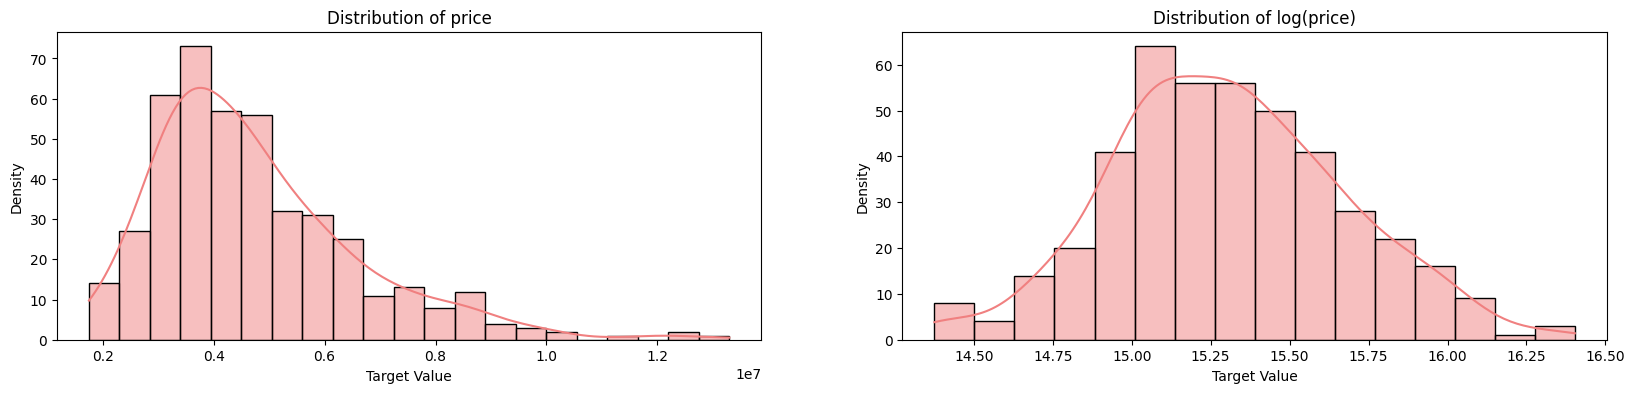

In [14]:
target_info(df_train, TARGET_NAME, "log")

The target is normal, but right-skewed. Better be transformed to approach normality (heteroscedasticity concern).

In [15]:
df_train.loc[:, TARGET_NAME] = np.log(df_train[TARGET_NAME])
df_test.loc[:, TARGET_NAME] = np.log(df_test[TARGET_NAME])

#### Continuous features' distributions and transformation

Performed to remove non-linear dependencies and add linear - "feature engineering", so to say.

Generating diagnostic profiling for: area


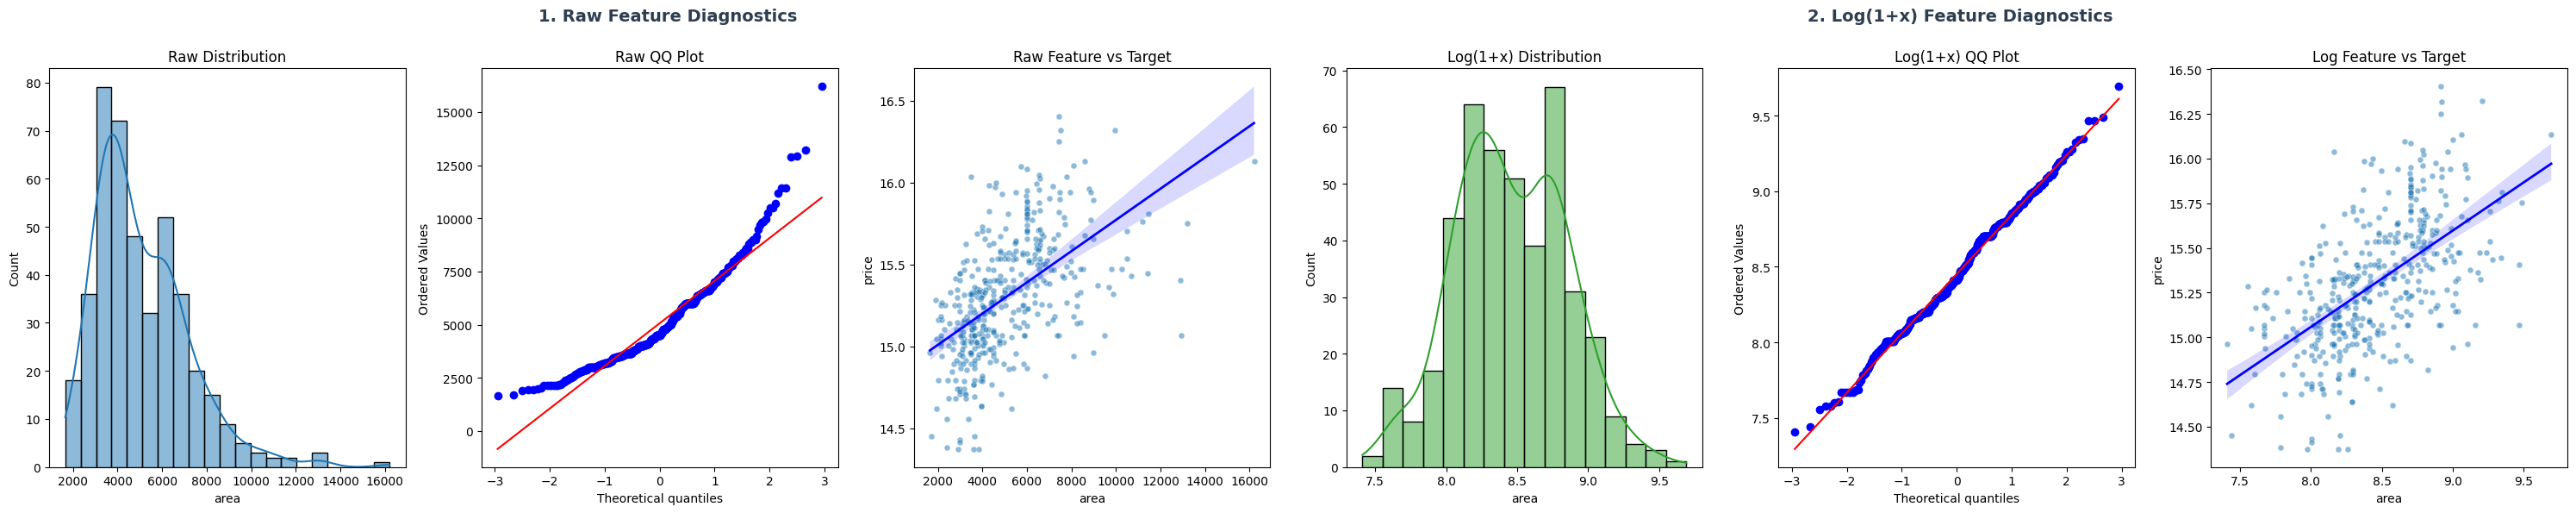

In [16]:
plot_features_against_target(df_train, ['area'], TARGET_NAME, None)

```txt
Analysis:
    Distributions:
        - area (continuous) - normal; right-skewed, log transformation helps (to simplify; fix nonlinear relationships)
        - bedrooms - discrete; shouldn't be transformed
        - bathrooms - discrete; shouldn't be transformed

Outliers:
    - area: present, distribution is normal after transformation.
    
Action plan:
    - remove extreme values visually (conservatively) to stabilize central tendencies
    - remove outliers based on the classic standard deviation method (3 stds)
```

#### Dealing with outliers

##### Visual conservative removal

Generating diagnostic profiling for: area


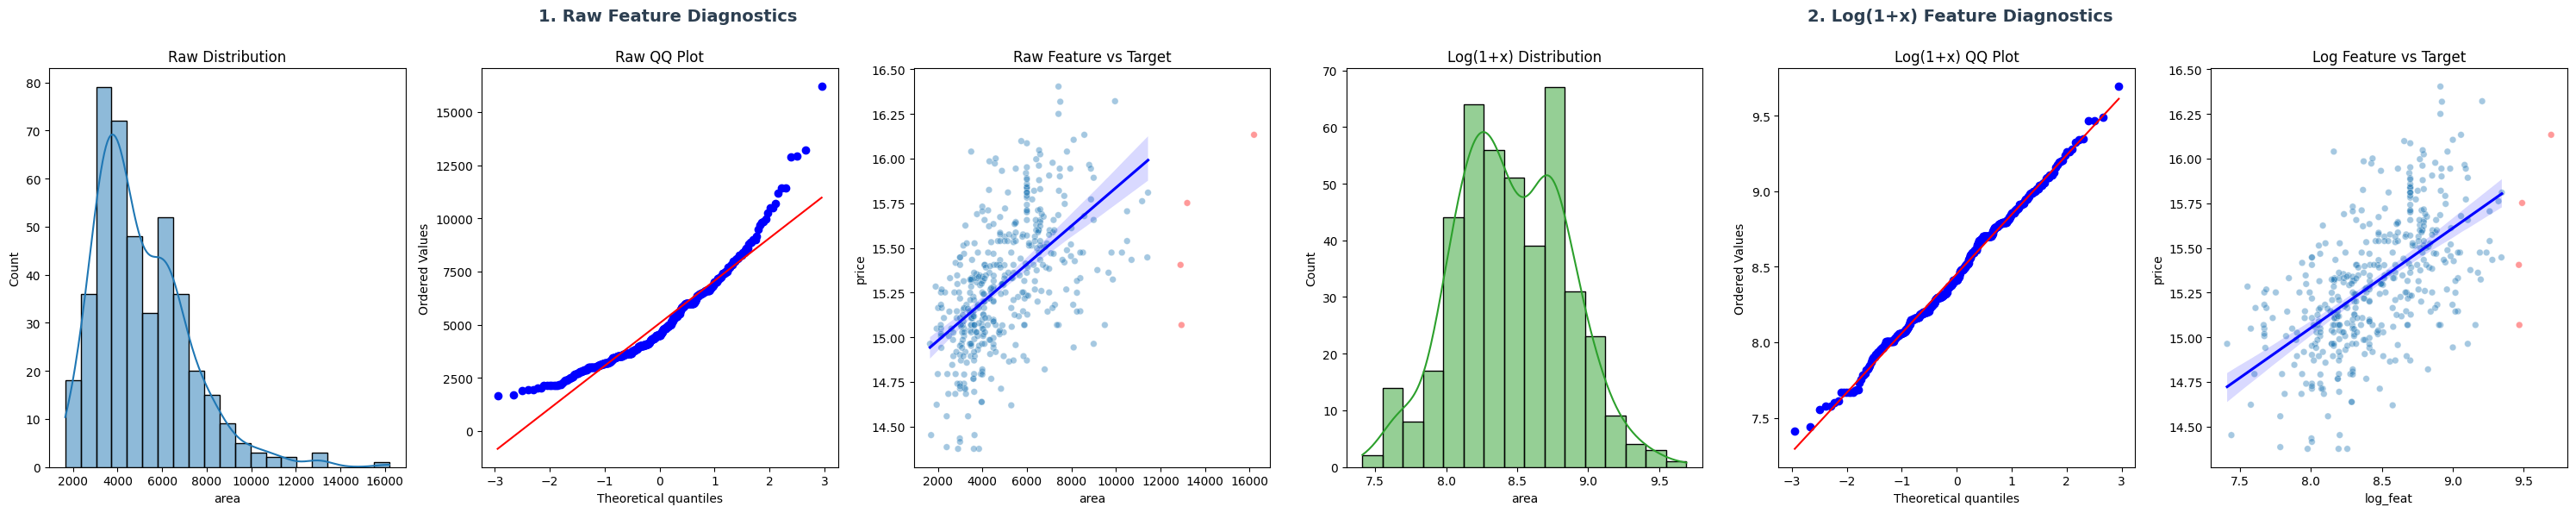

In [17]:
visual_outlier_mask = df_train['area'] >= 12000

preview_masks = {
    'area': visual_outlier_mask,
    TARGET_NAME: pd.Series(False, index=df_train.index),
}

plot_features_against_target(df_train, ['area'], 'price', imputed_masks=preview_masks)

##### Removal using statistical strategies

In [18]:
# --- Step 1: Conservative Manual/Visual Cleaning via Querying ---
df_cleaned = df_train.query("area < 12000") # keep rows that DO NOT match our outlier criteria (we want to delete area > 12000)
print(f"To clean visually: {len(df_train)-len(df_cleaned)} outliers")

# --- Step 2: Apply Log Transformation to Stabilize the Distribution
df_train.loc[:, 'area'] = np.log1p(df_train['area'])
df_test.loc[:, 'area'] = np.log1p(df_test['area'])

# --- Step 3: Calculate the Statistical Parameters (ONLY on the training data) ---
mean_log_area = df_train['area'].mean()
std_log_area = df_train['area'].std()

# --- Step 4: Establish our boundaries using the 3-sigma rule (covering 99.7% of normal data) ---
lower_boundary = mean_log_area - (3 * std_log_area)
upper_boundary = mean_log_area + (3 * std_log_area)
print(f"Log1p(Area) Clean Boundaries: {lower_boundary:.4f} to {upper_boundary:.4f}")

# --- Step 5: Filter out the std statistical outliers ---
final_train_df = df_train.query("@lower_boundary <= area <= @upper_boundary").copy()
print(f"Rows deleted by the final Standard Deviation cleaning: {len(df_train) - len(final_train_df)}")

To clean visually: 4 outliers
Log1p(Area) Clean Boundaries: 7.2763 to 9.6299
Rows deleted by the final Standard Deviation cleaning: 1


#### Standardization

It is not obligatory, but reduces large values for computational efficiency and optimizes gradient descent, also mandatory if using regularization.

In [19]:
X_train = df_train.drop(columns=[TARGET_NAME])
X_test = df_test.drop(columns=[TARGET_NAME])

# create and fit the scaler on TRAINING numerical data
scaler = StandardScaler().fit(X_train)

# transform the data
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index) # <--- .transform() strips away the index column + it doesn't return column names!
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 2. Safely combine features and target (Indices match perfectly)
df_train_scaled = pd.concat([X_train_scaled, df_train[[TARGET_NAME]]], axis=1)
df_test_scaled = pd.concat([X_test_scaled, df_test[[TARGET_NAME]]], axis=1)

display(df_train_scaled.head())
display(df_test_scaled.head())

,area,bedrooms,bathrooms,price
138,0.164113,0.084228,-0.567518,15.562970
80,0.629346,0.084228,-0.567518,15.706965
358,-0.760589,-1.266538,-0.567518,15.135932
132,0.264192,0.084228,-0.567518,15.575091
98,0.872556,0.084228,1.514983,15.654948


,area,bedrooms,bathrooms,price
138,0.164113,0.084228,-0.567518,15.562970
80,0.629346,0.084228,-0.567518,15.706965
358,-0.760589,-1.266538,-0.567518,15.135932
132,0.264192,0.084228,-0.567518,15.575091
98,0.872556,0.084228,1.514983,15.654948


### Assumptions for predictive power + model complexity evaluation

In order to make sense of what we're doing, the linearity must be justified. THe justification implies certain assumptions hold.

The project doesn't require inference, so only the predictive power assumptions will be researched.

#### Assumption 1: Multicollinearity concern

Since we're only considering predictive power and not statistical inference, we should only take care of **perfect** multicollinearity.

In [20]:
detect_perfect_multicollinearity_via_rank(df_train_scaled, TARGET_NAME)

Matrix rank: 3 / 3 features


3

Perfect multicollinearity is absent. \
**Conclusion**: The assumption holds.

In [21]:
# (Purely for the sake of interest) Checking how high the present collinearity is (VIF + condition index):
perform_advanced_vif_analysis(df_train_scaled, TARGET_NAME)

,feature,VIF,matrix_kappa
0,bathrooms,1.194506,1.559474
1,bedrooms,1.177860,1.559474
2,area,1.049026,1.559474


#### Assumptions 2,3: Homoscedasticity + Linearity

Fit a baseline model, obtain the residuals

In [22]:
# prepare the data
X_train_scaled = X_train_scaled.to_numpy()
y_train = df_train_scaled[TARGET_NAME].to_numpy().ravel() # 'ravel' enforces 1D (n_samples,)

# fit the baseline
LR_baseline = LinearRegression(fit_intercept=True)
LR_baseline.fit(X_train_scaled, y_train)

# predict to calculate residuals
y_pred = LR_baseline.predict(X_train_scaled)
residuals = y_train - y_pred

# evaluate
baseline_mse = mean_squared_error(y_train, y_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_train, y_pred)

print(f"Baseline MSE = {baseline_mse:.4f}")
print(f"Baseline RMSE = {baseline_rmse:.4f}")
print(f"Baseline R2 = {baseline_r2:.4f}")

Baseline MSE = 0.0676
Baseline RMSE = 0.2599
Baseline R2 = 0.5000


While the **normality of residuals assumption** is purely for inference, the Breusch-Pagan test requires it to hold in order to work:

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_19764\1743597576.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="upper right")  # Added to display the labels clearly


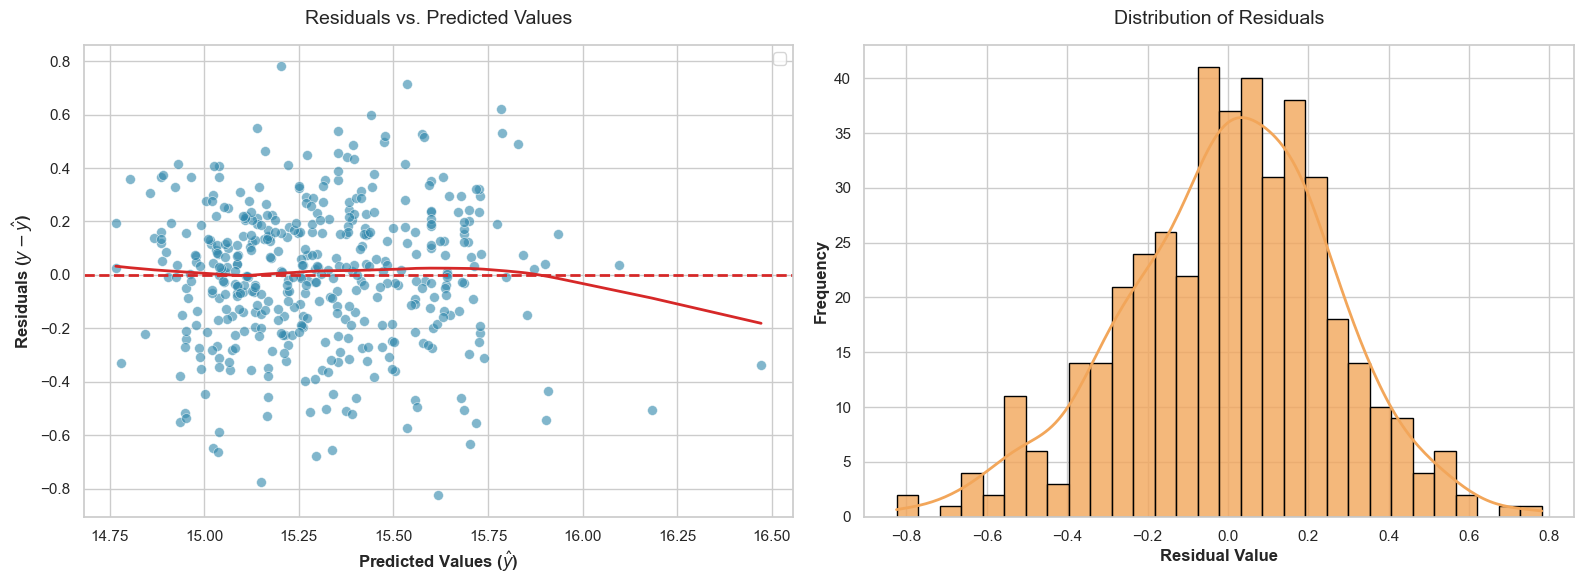

In [23]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Residuals vs. Predicted (Heteroscedasticity & Linearity Check) ---
sns.scatterplot(
    x=y_pred,
    y=residuals,
    ax=axes[0],
    color="#2E86AB",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    s=50,
)

# LOWESS Trendline to catch non-linearity visual cues
sns.regplot(
    x=y_pred,
    y=residuals,
    scatter=False,
    lowess=True,
    ax=axes[0],
    line_kws={"color": "#D62828", "linewidth": 2, "label": "Residual Trend"}
)

axes[0].axhline(y=0, color="#D62828", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Values ($\\hat{y}$)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Residuals ($y - \\hat{y}$)", fontsize=12, fontweight="bold")
axes[0].set_title("Residuals vs. Predicted Values", fontsize=14, pad=15)
axes[0].legend(loc="upper right")  # Added to display the labels clearly

# --- Plot 2: Distribution of Residuals ---
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    ax=axes[1],
    color="#F2A65A",
    edgecolor="black",
    alpha=0.8,
    line_kws={"linewidth": 2, "color": "#D62828"},
)
axes[1].set_xlabel("Residual Value", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")
axes[1].set_title("Distribution of Residuals", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

The distribution of residuals looks normal, slightly skewed to the left. We may claim **the assumption of residual normality** holds.

Based on the scatter plot, the residuals are distributed evenly and don't form funnel-like or irregular shapes, scattered around 0, which preliminarily suggests **no heteroscedasticity**. 

However, the LOWESS line (locally weighted scatterplot smoothing) curves towards the end. It **violates the linearity assumption**. But since the data almost perfectly fit linear dependency, it is fair to assume such bend is caused by leverage points, essentially anomalies, and NOT by non-linear patterns. \
**Solution**: Utilizing Cook's distances, remove the points above the threshold. If the metrics don't worsen/improve and the bend is gone, the anomaly hypothesis is confirmed and linearity holds.

In [24]:
# Utilizing statmodels's OLS because it autocomputes Cook's distances
X_train_scaled_with_constant = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_scaled_with_constant)
fit_model = ols_model.fit()
y_pred = fit_model.predict(X_train_scaled_with_constant)

baseline_mse = mean_squared_error(y_train, y_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_train, y_pred)

print(f"Baseline MSE = {baseline_mse:.4f}")
print(f"Baseline RMSE = {baseline_rmse:.4f}")
print(f"Baseline R2 = {baseline_r2:.4f}")

cooks_all, cooks_outliers = get_cooks_distances(df_train_scaled, fit_model)

Baseline MSE = 0.0676
Baseline RMSE = 0.2599
Baseline R2 = 0.5000

4/n threshold = 0.00923788
Count above 4/n (baseline anomalies): 27
Count above 1.0 (severe anomalies): 0

Top 20 Cook's D values (descending):
499    0.109152
89     0.039286
403    0.031602
523    0.027220
4      0.025823
340    0.024502
7      0.023621
395    0.022850
509    0.018338
13     0.017012
229    0.016440
0      0.016038
8      0.015640
2      0.013721
452    0.013172
271    0.013000
3      0.011838
541    0.011048
401    0.010853
487    0.010848
Name: cooks_d, dtype: float64


No severe outliers (>1.0), but 27 potential leverage points. For each feature, we are going to plot these points to assess where the imbalance comes from

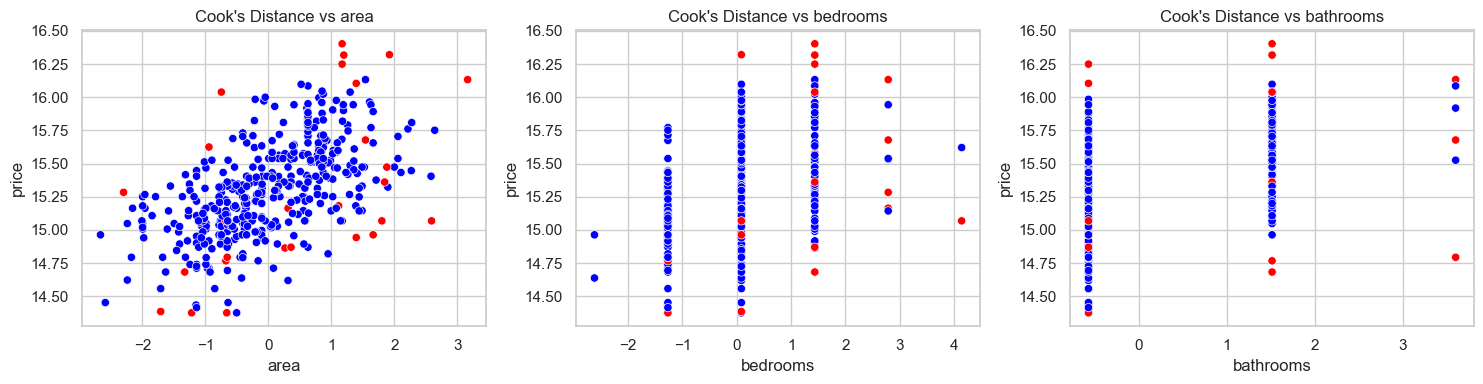

In [25]:
# Create a proper full-length boolean mask initialized to False
cooks_boolean_series = pd.Series(False, index=df_train_scaled.index)

# Set the 27 high-influence positions to True
cooks_boolean_series.loc[cooks_outliers.index] = True

features_to_plot = X_train.columns.to_numpy()
n_cols = 3
n_rows = math.ceil(len(features_to_plot) / n_cols)

# Create the figure and subplots grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

for i, feature in enumerate(features_to_plot):
    # Select the current subplot axis
    ax = axes[i]

    # Create the scatterplot on the specific axis (ax=ax)
    sns.scatterplot(
        data=df_train_scaled,
        x=feature,
        y=TARGET_NAME,
        hue=cooks_boolean_series,
        palette={True: "red", False: "blue"},
        legend=False,
        ax=ax,
    )

    # Set dynamic title for the specific subplot
    ax.set_title(f"Cook's Distance vs {feature}")

# Hide any empty subplots at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and display the final grid
plt.tight_layout()
plt.show()

It looks like the leverage points target pricy houses mainly, but the anomalies are multivariate.

In [26]:
# copy original data
x_train_df_no_cooks = X_train_scaled.copy()
y_train_df_no_cooks = pd.DataFrame(y_train, index=df_train_scaled.index, columns=[TARGET_NAME])

# create a mask where true values mean "flagged by Cook"
cooks_outlier_positions = df_train_scaled.index.isin(cooks_outliers.index)

# filter out the dfs to leave out the Cook's anomalies
x_train_no_outliers = X_train_scaled[~cooks_outlier_positions]
y_train_no_outliers_df = y_train_df_no_cooks.drop(index=cooks_outliers.index)

# Prepare the target
y_train_no_outliers = y_train_no_outliers_df.to_numpy().ravel()

In [27]:
# fit the baseline the second time with no anomalies
LR_baseline_no_cooks = LinearRegression(fit_intercept=True)
LR_baseline_no_cooks.fit(x_train_no_outliers, y_train_no_outliers)

# predict to compute residuals
y_pred = LR_baseline_no_cooks.predict(x_train_no_outliers)
residuals = y_train_no_outliers - y_pred

# evaluate
baseline_mse = mean_squared_error(y_train_no_outliers, y_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_train_no_outliers, y_pred)

print(f"Baseline MSE = {baseline_mse:.4f}")
print(f"Baseline RMSE = {baseline_rmse:.4f}")
print(f"Baseline R2 = {baseline_r2:.4f}")

Baseline MSE = 0.0516
Baseline RMSE = 0.2272
Baseline R2 = 0.5623


The scores have improved greatly.

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_19764\1743597576.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="upper right")  # Added to display the labels clearly


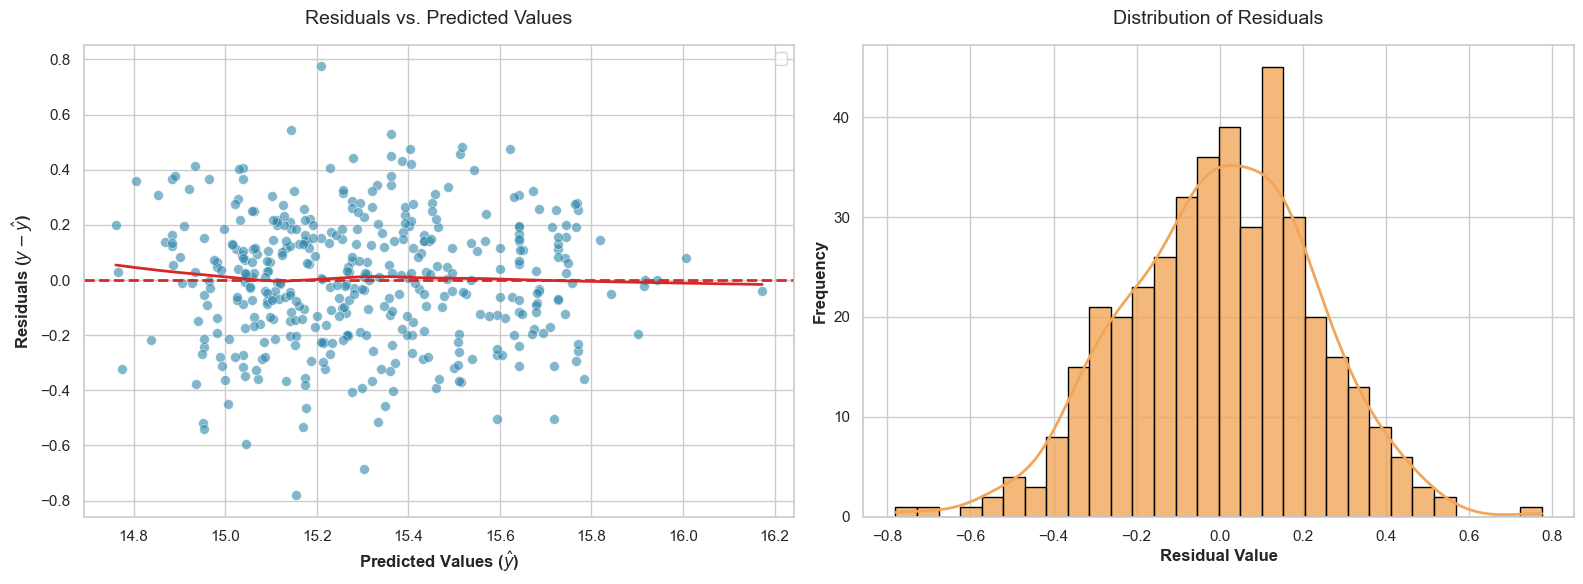

In [28]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Residuals vs. Predicted (Heteroscedasticity & Linearity Check) ---
sns.scatterplot(
    x=y_pred,
    y=residuals,
    ax=axes[0],
    color="#2E86AB",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    s=50,
)

# LOWESS Trendline to catch non-linearity visual cues
sns.regplot(
    x=y_pred,
    y=residuals,
    scatter=False,
    lowess=True,
    ax=axes[0],
    line_kws={"color": "#D62828", "linewidth": 2, "label": "Residual Trend"}
)

axes[0].axhline(y=0, color="#D62828", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Values ($\\hat{y}$)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Residuals ($y - \\hat{y}$)", fontsize=12, fontweight="bold")
axes[0].set_title("Residuals vs. Predicted Values", fontsize=14, pad=15)
axes[0].legend(loc="upper right")  # Added to display the labels clearly

# --- Plot 2: Distribution of Residuals ---
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    ax=axes[1],
    color="#F2A65A",
    edgecolor="black",
    alpha=0.8,
    line_kws={"linewidth": 2, "color": "#D62828"},
)
axes[1].set_xlabel("Residual Value", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")
axes[1].set_title("Distribution of Residuals", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

The bend is gone along with the score improving. \
**Conclusion**: the anomaly hypothesis is confirmed, the linearity assumption holds.

In [29]:
# "save" the changes
X_train_scaled = x_train_no_outliers
y_train = y_train_no_outliers

In [30]:
# prepare the exact same features for BP test, but manually add the constant since statsmodels requires it explicitly
X_with_a_constant = sm.add_constant(X_train_scaled)
breusch_pagan_test(X_with_a_constant, residuals)

Fail to reject H0: No Heteroscedasticity detected.


LM Statistic,R2,LM p-value,F-value,F p-value
2.377491,0.005856,0.497838,0.789311,0.500386


BP also confirms **no linear heteroscedasticity**.

In [31]:
white_test(X_with_a_constant, residuals)

Fail to reject H0: No Heteroscedasticity detected.


LM Statistic,R2,LM p-value,F-value,F p-value
6.811144,0.016776,0.656775,0.750748,0.662222


White test confirms the data is linear as **no heteroscedasticity found in complex (non-linear) terms**. \
**Conclusion**: no heteroscedasticity. The assumption holds.

#### Assumption 4: Representative Sample

Ensures the data is split correctly (compares distributions; done on live data in production).

In [32]:
# Drop the Cook's distance outliers from the training DataFrame to match the clean training set
df_train_scaled_clean = df_train_scaled.drop(index=cooks_outliers.index)

psi_scores = calculate_feature_psi(
    x_sample=df_train_scaled_clean,
    x_evaluation=df_test_scaled,
    target_name=TARGET_NAME,
    num_bins=10,
)

print("\n--- Population Stability Index (PSI) Scores ---")
print(psi_scores)


--- Population Stability Index (PSI) Scores ---
area         0.057306
bedrooms     0.020857
bathrooms    0.000002
Name: PSI_Score, dtype: float64


All features are below the $0.1$ threshold. \
**The conclusion**: The assumption holds, we may state that training data perfectly represents the test set.

### Compute baseline scores to compare against

In [42]:
# predict
y_pred = LR_baseline_no_cooks.predict(X_test_scaled.to_numpy())
y_test = df_test[TARGET_NAME].to_numpy().reshape(-1,1)

# evaluate
baseline_mse = mean_squared_error(y_test, y_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, y_pred)

print(f"Baseline test MSE =     {baseline_mse:.4f}")
print(f"Baseline test RMSE =    {baseline_rmse:.4f}")
print(f"Baseline testR2 =       {baseline_r2:.4f}")

Baseline test MSE =     0.0650
Baseline test RMSE =    0.2550
Baseline testR2 =       0.4324


### Save the data

In [ ]:
df_train_scaled_clean.to_csv(Path('data') / '3 train_post_EDA.csv', index=False)
df_test_scaled.to_csv(Path('data') / '3 test_post_EDA.csv', index=False)